# 02 — Preprocessing & Feature Engineering
## From Raw OHLCV to a Leak-Free Model-Ready Panel

**Jarvis Capital — Deep Learning Equity Signal Capstone**

This notebook converts 259k rows of raw prices into the exact matrices every model in notebooks 03–05 will consume. The design principle throughout is **zero look-ahead**: at any date *t*, every feature must be computable from information available at the close of day *t*. Three rules enforce it:

1. **Trailing windows only.** Every indicator uses `rolling`/`ewm` over *past* data. The one deliberate forward shift is the target itself (`shift(-1)` — tomorrow's return).
2. **Strictly temporal splits.** Train 2005–2018 → validation 2019–2021 → test 2022–2025. No shuffling across time, and the test years stay untouched until notebook 06.
3. **Scaler fit on train only.** The `StandardScaler` learns its means and variances from the training years, then merely *applies* them to validation and test. Fitting on the full sample would leak the future's distribution into the past.

All indicator implementations live in [`src/features.py`](../src/features.py) — hand-built, documented, and unit-testable, rather than imported from a black-box TA library.

In [1]:
import sys, warnings, json
sys.path.append("..")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from scipy.stats import spearmanr
from sklearn.preprocessing import StandardScaler

from src import config, data, features, plotting
from src.features import FEATURE_COLUMNS
from src.plotting import (BLUE, ORANGE, AQUA, MUTED, INK_2, GRID, GOOD, CRITICAL,
                          direct_label, fmt_pct, subtitle, save_figure)

plotting.apply_style()
config.set_seed()
print(f"{len(FEATURE_COLUMNS)} features:", FEATURE_COLUMNS)

17 features: ['ret_1d', 'ret_5d', 'ret_21d', 'ret_63d', 'vol_21d', 'atr_14', 'rsi_14', 'macd_hist', 'boll_pct_b', 'boll_bw', 'px_vs_sma10', 'px_vs_sma50', 'volume_z', 'vix', 'vix_chg_5d', 'treasury_10y', 'treasury_chg_21d']


---
## 1. The Feature Set — 17 Features, Six Economic Rationales

| Group | Features | Why it might predict tomorrow |
|---|---|---|
| **Momentum** | `ret_1d`, `ret_5d`, `ret_21d`, `ret_63d` | Persistence/reversal at daily→quarterly horizons — the classic anomaly literature |
| **Volatility state** | `vol_21d`, `atr_14` | EDA showed volatility clusters; a stock's risk state conditions its return distribution |
| **Mean-reversion** | `rsi_14`, `macd_hist`, `boll_pct_b`, `boll_bw` | Overbought/oversold oscillators; band position and squeeze |
| **Trend location** | `px_vs_sma10`, `px_vs_sma50` | Price relative to short/medium moving averages |
| **Volume anomaly** | `volume_z` | Abnormal volume often precedes or confirms moves |
| **Market context** | `vix`, `vix_chg_5d`, `treasury_10y`, `treasury_chg_21d` | The regime variables from the EDA — shared across all stocks on a given date |

The target is **`target` = next-day simple return** — a regression framing. Direction (sign) is derived from it for classification-style metrics.

In [2]:
prices = data.load_prices()
market = data.load_market()

panel = features.build_feature_panel(prices, market)
print(f"Feature panel: {panel.shape[0]:,} rows x {panel.shape[1]} columns")
print(f"Tickers: {panel['Ticker'].nunique()}   Date range: {panel['Date'].min().date()} -> {panel['Date'].max().date()}")
print(f"NaNs remaining: {panel.isna().sum().sum()}")
panel.head(3)

Feature panel: 244,979 rows x 20 columns
Tickers: 48   Date range: 2005-04-05 -> 2025-12-29
NaNs remaining: 0


,Date,Ticker,ret_1d,ret_5d,ret_21d,ret_63d,vol_21d,atr_14,rsi_14,macd_hist,boll_pct_b,boll_bw,px_vs_sma10,px_vs_sma50,volume_z,vix,vix_chg_5d,treasury_10y,treasury_chg_21d,target
0,2005-04-05,AAPL,0.019469,0.003353,-0.021491,0.323747,0.321422,0.029470,51.341401,-0.004548,0.563070,0.113407,-0.003805,0.015483,-0.334592,13.68,-0.055901,4.470,0.160,0.010504
1,2005-04-06,AAPL,0.010504,-0.010981,-0.009824,0.324054,0.323795,0.028633,53.650288,-0.003081,0.639258,0.111551,0.007857,0.022704,-0.913883,13.15,-0.035924,4.436,0.132,0.029057
2,2005-04-07,AAPL,0.029057,0.045356,0.074759,0.350697,0.279495,0.028296,59.443427,-0.000231,0.879838,0.104759,0.034654,0.048602,-0.458386,12.33,-0.120542,4.472,0.097,0.004133


### Sanity check: no feature can see the future

A cheap but powerful test — recompute the features on a *truncated* copy of the data and confirm the overlapping rows are identical. If any indicator used future information, truncation would change past values.

In [3]:
cutoff = "2015-06-30"
prices_trunc = prices[prices["Date"] <= cutoff]
market_trunc = market[market.index <= cutoff]
panel_trunc = features.build_feature_panel(prices_trunc, market_trunc, tickers=["AAPL", "JPM"])

# align on (Date, Ticker) keys - the truncated run loses each ticker's final
# row (its next-day target lies beyond the cutoff), so positions shift
merged = panel.merge(panel_trunc, on=["Date", "Ticker"], suffixes=("_full", "_trunc"))
identical = all(
    np.allclose(merged[f + "_full"], merged[f + "_trunc"]) for f in FEATURE_COLUMNS
)
print(f"Overlapping rows compared: {len(merged):,}")
print(f"Features identical when future data is removed: {identical}")
assert identical, "LEAK: some feature changes when future rows are deleted!"


Overlapping rows compared: 5,138
Features identical when future data is removed: True


---
## 2. Temporal Splits — 14 Years Train, 3 Validation, 4 Test

The split is by **date**, never by row: all 48 stocks cross from train to validation on the same day. The test period (2022–2025) contains a bear market, a recovery, and a melt-up — a genuinely demanding out-of-sample stretch.

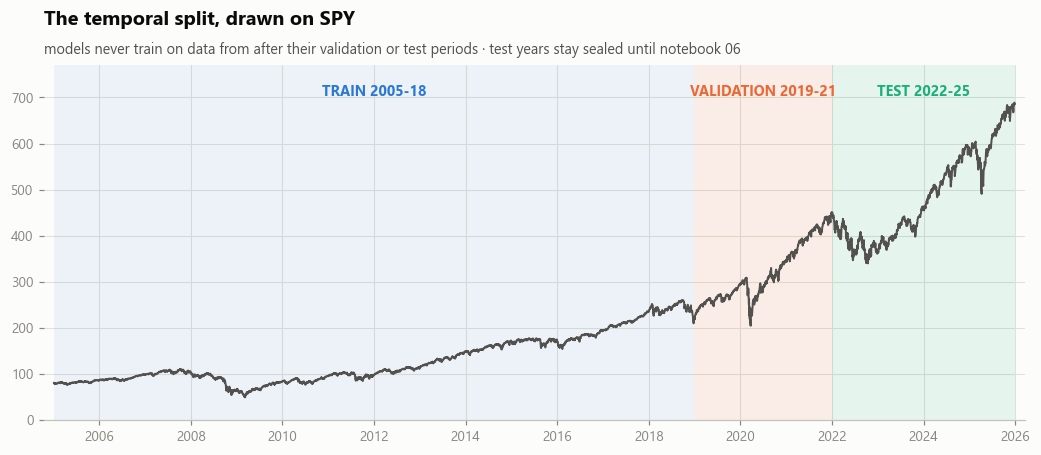

,rows,start,end,share
train,160595,2005-04-05,2018-12-31,0.655546
validation,36336,2019-01-02,2021-12-31,0.148323
test,48048,2022-01-03,2025-12-29,0.196131


In [4]:
train, val, test = data.temporal_split(panel, date_col="Date")

split_summary = pd.DataFrame({
    "rows": [len(train), len(val), len(test)],
    "start": [d["Date"].min().date() for d in (train, val, test)],
    "end": [d["Date"].max().date() for d in (train, val, test)],
    "share": [len(d) / len(panel) for d in (train, val, test)],
}, index=["train", "validation", "test"])

# ── Timeline visual: SPY price with the split bands ──
spy = data.pivot_field(prices, "Close")["SPY"].dropna()
fig, ax = plt.subplots(figsize=(11.5, 4.2))
bands = [(spy.index[0], pd.Timestamp(config.TRAIN_END), "TRAIN 2005-18", BLUE, 0.07),
         (pd.Timestamp(config.TRAIN_END), pd.Timestamp(config.VAL_END), "VALIDATION 2019-21", ORANGE, 0.10),
         (pd.Timestamp(config.VAL_END), spy.index[-1], "TEST 2022-25", AQUA, 0.10)]
for lo, hi, label, c, alpha in bands:
    ax.axvspan(lo, hi, color=c, alpha=alpha, lw=0)
    ax.text(lo + (hi - lo) / 2, spy.max() * 1.02, label, ha="center",
            fontsize=9.5, fontweight="bold", color=c)
ax.plot(spy.index, spy, color=INK_2, lw=1.3)
ax.set_ylim(0, spy.max() * 1.12)
ax.set_title("The temporal split, drawn on SPY")
subtitle(ax, "models never train on data from after their validation or test periods \u00b7 test years stay sealed until notebook 06")
plotting.year_axis(ax)
ax.margins(x=0.01)
save_figure(fig, "prep_temporal_split")
plt.show()
split_summary

---
## 3. Scaling — Fit on Train, Apply Everywhere

Neural networks train poorly on features with wildly different magnitudes (`vix` ≈ 20 vs `ret_1d` ≈ 0.001). We standardize every feature to zero mean / unit variance **using training-years statistics only**, and persist the scaler so notebooks 03–06 and any future production pipeline apply *identical* transforms.

In [5]:
scaler = StandardScaler().fit(train[FEATURE_COLUMNS])

def apply_scaler(df):
    out = df.copy()
    out[FEATURE_COLUMNS] = scaler.transform(df[FEATURE_COLUMNS])
    return out

train_s, val_s, test_s = map(apply_scaler, (train, val, test))

# Why train-only fitting matters: several features drifted between eras
drift = pd.DataFrame({
    "train mean": train[FEATURE_COLUMNS].mean(),
    "test mean": test[FEATURE_COLUMNS].mean(),
    "train std": train[FEATURE_COLUMNS].std(),
    "test std": test[FEATURE_COLUMNS].std(),
}).loc[["vix", "treasury_10y", "vol_21d", "ret_21d"]]
print("Distribution drift between train and test eras (raw units):")
drift.round(3)

Distribution drift between train and test eras (raw units):


,train mean,test mean,train std,test std
vix,18.639,19.274,9.029,5.629
treasury_10y,2.984,3.853,0.997,0.693
vol_21d,0.256,0.270,0.194,0.128
ret_21d,0.013,0.012,0.082,0.086


In [6]:
# After scaling, train is centered by construction; test is NOT - that gap is real
# distribution shift the models will face in production, so we keep it visible.
check = pd.DataFrame({
    "train mean (scaled)": train_s[FEATURE_COLUMNS].mean(),
    "test mean (scaled)": test_s[FEATURE_COLUMNS].mean(),
}).round(2)
check.T

,ret_1d,ret_5d,ret_21d,ret_63d,vol_21d,atr_14,rsi_14,macd_hist,boll_pct_b,boll_bw,px_vs_sma10,px_vs_sma50,volume_z,vix,vix_chg_5d,treasury_10y,treasury_chg_21d
train mean (scaled),0.0,0.00,0.00,-0.00,0.00,-0.00,-0.00,-0.0,0.00,-0.00,0.00,0.00,0.00,0.00,0.00,0.00,-0.00
test mean (scaled),-0.0,-0.01,-0.01,-0.03,0.07,0.04,-0.08,0.0,-0.06,0.15,-0.01,-0.02,0.01,0.07,-0.01,0.87,0.27


**Note the non-zero test means** — e.g. `treasury_10y` sits far from its train-era average (rates were near zero for much of 2005–2018, then 4%+ in 2022–25). This is honest: the model will meet 2022–25 exactly as unfamiliar as production would be.

---
## 4. How Much Signal Is There? Per-Feature Information Coefficients

The **IC** — Spearman rank correlation between a feature today and the return tomorrow — measured on the training years. In liquid equities, |IC| of 0.02–0.05 is normal and tradeable at scale; 0.10+ on next-day returns usually means a bug.

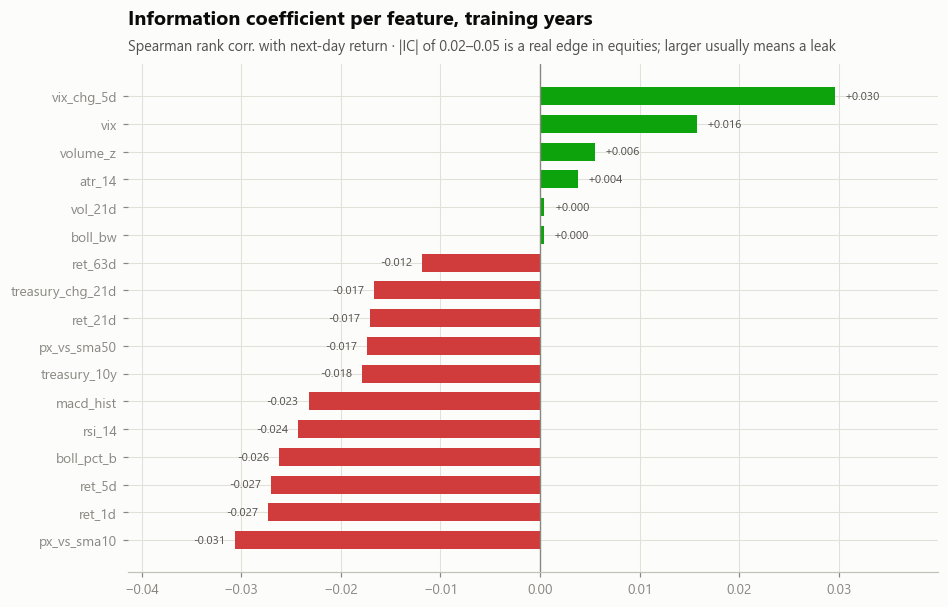

In [7]:
ic = {}
for f in FEATURE_COLUMNS:
    ic[f], _ = spearmanr(train[f], train["target"])
ic = pd.Series(ic).sort_values()

fig, ax = plt.subplots(figsize=(9.5, 6))
colors = [CRITICAL if v < 0 else GOOD for v in ic]
ax.barh(range(len(ic)), ic.values, color=colors, height=0.65)
ax.set_yticks(range(len(ic)))
ax.set_yticklabels(ic.index, fontsize=9)
ax.axvline(0, color=MUTED, lw=0.9)
ax.set_title("Information coefficient per feature, training years")
subtitle(ax, "Spearman rank corr. with next-day return \u00b7 |IC| of 0.02\u20130.05 is a real edge in equities; larger usually means a leak")
for i, v in enumerate(ic.values):
    ax.text(v + (0.001 if v >= 0 else -0.001), i, f"{v:+.3f}", va="center",
            ha="left" if v >= 0 else "right", fontsize=7.5, color=INK_2)
ax.set_xlim(ic.min() * 1.35, ic.max() * 1.35)
save_figure(fig, "prep_information_coefficients")
plt.show()

**Reading:** short-horizon reversal (`ret_1d`, `rsi_14`, `boll_pct_b` negative) is the strongest pattern — stocks that jumped today tend to give a little back tomorrow. Everything is small, exactly as the EDA's autocorrelation analysis predicted. The deep learning question is whether *nonlinear combinations* of these weak signals carry more than each does alone.

### Feature redundancy

Momentum features at overlapping horizons are correlated by construction — worth knowing before interpreting any model's weights.

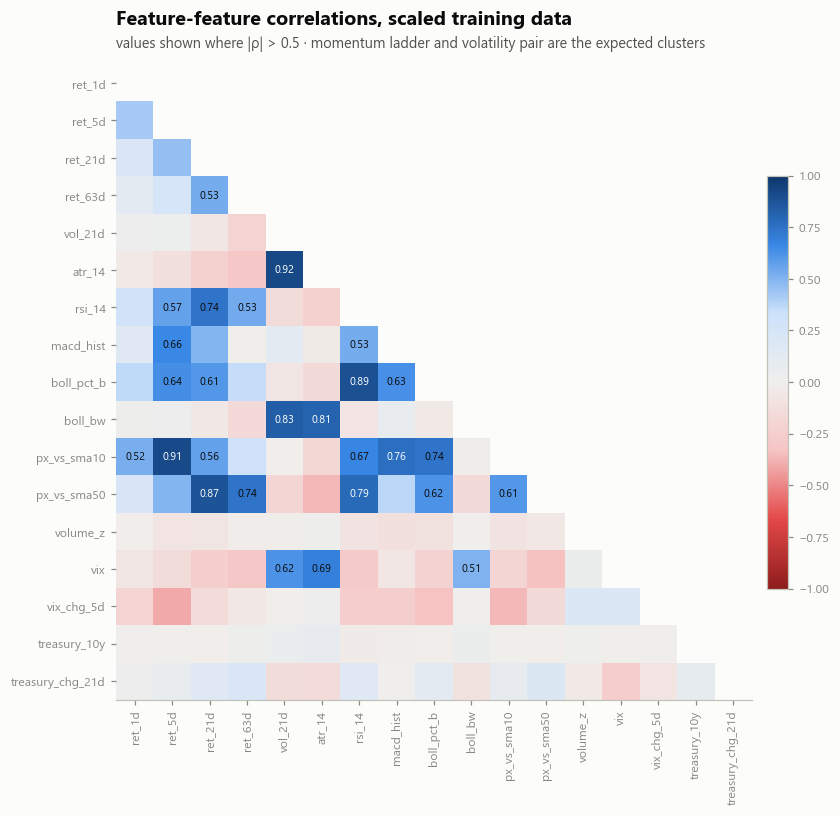

In [8]:
fcorr = train_s[FEATURE_COLUMNS].corr()
mask = np.triu(np.ones_like(fcorr, dtype=bool))

fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(np.where(mask, np.nan, fcorr.values),
               cmap=plotting.CMAP_DIV.reversed(), vmin=-1, vmax=1)
ax.set_xticks(range(len(FEATURE_COLUMNS))); ax.set_xticklabels(FEATURE_COLUMNS, rotation=90, fontsize=8)
ax.set_yticks(range(len(FEATURE_COLUMNS))); ax.set_yticklabels(FEATURE_COLUMNS, fontsize=8)
ax.grid(False)
for i in range(len(FEATURE_COLUMNS)):
    for j in range(i):
        v = fcorr.values[i, j]
        if abs(v) > 0.5:
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=7,
                    color="white" if abs(v) > 0.75 else plotting.INK)
cbar = fig.colorbar(im, ax=ax, shrink=0.65, pad=0.02); cbar.ax.tick_params(labelsize=8)
ax.set_title("Feature-feature correlations, scaled training data")
subtitle(ax, "values shown where |\u03c1| > 0.5 \u00b7 momentum ladder and volatility pair are the expected clusters")
save_figure(fig, "prep_feature_correlation")
plt.show()

---
## 5. Persist the Artifacts

Everything downstream loads from `data/processed/` — the notebooks never rebuild features, guaranteeing every model sees byte-identical inputs.

In [9]:
out = config.PROCESSED_DIR
out.mkdir(parents=True, exist_ok=True)

train_s.to_parquet(out / "train.parquet", index=False)
val_s.to_parquet(out / "val.parquet", index=False)
test_s.to_parquet(out / "test.parquet", index=False)
joblib.dump(scaler, config.MODELS_DIR / "feature_scaler.pkl")
with open(out / "feature_columns.json", "w") as f:
    json.dump(FEATURE_COLUMNS, f, indent=2)

# Also persist the unscaled panel: the backtester needs RAW next-day returns
panel.to_parquet(out / "panel_raw.parquet", index=False)

for p in sorted(out.glob("*")) + [config.MODELS_DIR / "feature_scaler.pkl"]:
    print(f"  {p.name:28s} {p.stat().st_size / 1e6:8.1f} MB")

  feature_columns.json              0.0 MB
  panel_raw.parquet                32.5 MB
  test.parquet                      7.0 MB
  train.parquet                    22.7 MB
  val.parquet                       5.2 MB
  feature_scaler.pkl                0.0 MB


---
## 6. What Notebooks 03–05 Receive

| Artifact | Contents | Used by |
|---|---|---|
| `train/val/test.parquet` | Scaled features + raw target, split temporally | All models |
| `panel_raw.parquet` | Unscaled features + target for the full panel | Backtester (raw returns), chart labeling |
| `feature_scaler.pkl` | Train-fitted `StandardScaler` | Production inference, notebook 06 |
| `feature_columns.json` | Canonical feature order | Everything (column order = model input order) |

**Leakage checklist confirmed in this notebook:**
- ✅ Features recomputed on truncated data are identical (no forward-looking windows)
- ✅ Splits are strictly temporal, by date, sealed test years
- ✅ Scaler fit on train only — test-era drift (rates!) left intact
- ✅ IC magnitudes are small and plausible (no suspicious 0.1+ correlations)

**Next:** notebook `03_feedforward_nn.ipynb` — the linear baseline the desk already runs, then feedforward networks trained with the full early-stopping loop.